⏳ Loading raw WELFake dataframe from local disk into memory...

MEASURE 1: WELFAKE TEXT LENGTH STRATA VARIANCE
📊 Dataset Profile Metrics: WELFake
 -> Total Text Samples:        72,095
 -> Fake Samples (0):           35,028
 -> Real Samples (1):           37,067
 -> Mean Word Count:             540.8 words
 -> Median Word Count:           399.0 words
 -> Max Word Count Outlier:      24,234 words
 -> Min Word Count Outlier:      0 words
 -> Micro-Texts (<30 words):     2,551 (3.5%)
 -> Long Essays (>1000 words):   8,853 (12.3%)


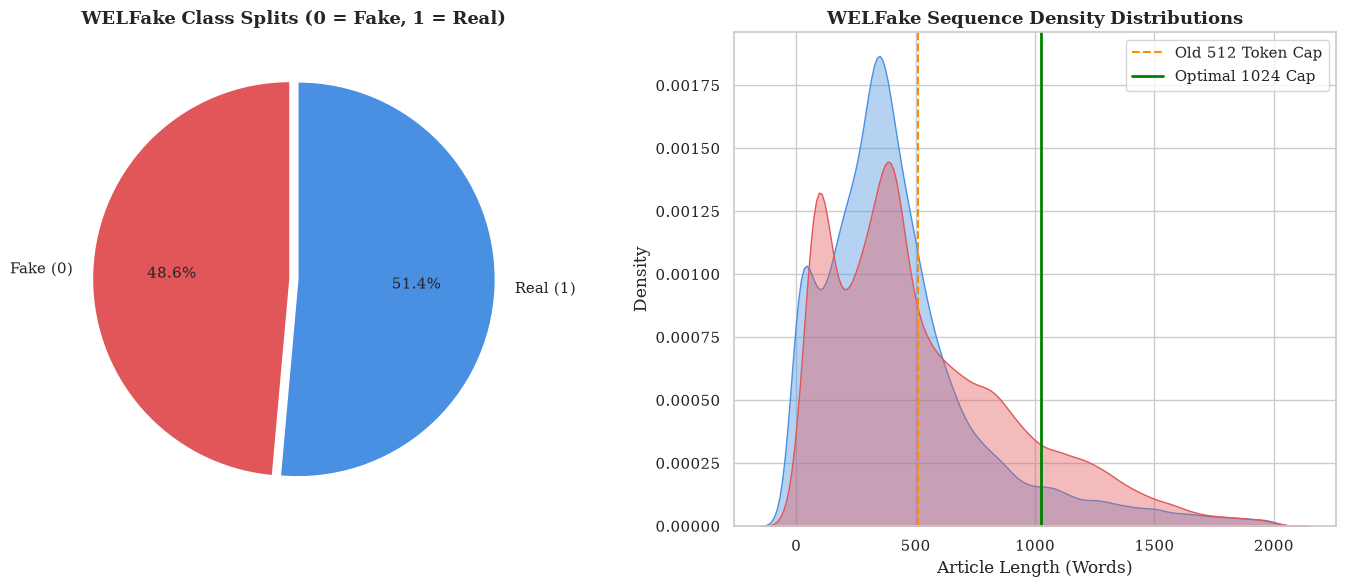


[Visual Output Saved] Plot graphic successfully generated as: welfake_profile_distributions.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

# WELFake label convention used throughout this notebook:
# 0 = Fake, 1 = Real

def analyze_and_visualize_welfake(welfake_path):
    print("⏳ Loading raw WELFake dataframe from local disk into memory...")

    if not os.path.exists(welfake_path):
        raise FileNotFoundError(f"Could not find WELFake dataset at the path: {welfake_path}")

    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})

    # Validate the expected binary labels.
    unexpected_labels = set(df['target'].dropna().unique()) - {0, 1}
    if unexpected_labels:
        raise ValueError(f"Unexpected labels found: {unexpected_labels}. Expected only 0 = Fake and 1 = Real.")

    df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

    print("\n" + "=" * 60)
    print("MEASURE 1: WELFAKE TEXT LENGTH STRATA VARIANCE")
    print("=" * 60)
    print("📊 Dataset Profile Metrics: WELFake")
    print(f" -> Total Text Samples:        {len(df):,}")
    print(f" -> Fake Samples (0):           {(df['target'] == 0).sum():,}")
    print(f" -> Real Samples (1):           {(df['target'] == 1).sum():,}")
    print(f" -> Mean Word Count:             {df['word_count'].mean():.1f} words")
    print(f" -> Median Word Count:           {df['word_count'].median():.1f} words")
    print(f" -> Max Word Count Outlier:      {df['word_count'].max():,} words")
    print(f" -> Min Word Count Outlier:      {df['word_count'].min()} words")
    print(f" -> Micro-Texts (<30 words):     {len(df[df['word_count'] < 30]):,} ({len(df[df['word_count'] < 30]) / len(df) * 100:.1f}%)")
    print(f" -> Long Essays (>1000 words):   {len(df[df['word_count'] > 1000]):,} ({len(df[df['word_count'] > 1000]) / len(df) * 100:.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Explicitly order classes so 0 is always Fake and 1 is always Real.
    class_counts = df['target'].value_counts().reindex([0, 1], fill_value=0)
    axes[0].pie(
        class_counts.values,
        labels=['Fake (0)', 'Real (1)'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#e15759', '#4a90e2'],
        explode=(0.02, 0.02)
    )
    axes[0].set_title("WELFake Class Splits (0 = Fake, 1 = Real)", weight='bold')

    sns.kdeplot(
        data=df[df['word_count'] <= 2000],
        x='word_count',
        hue='target',
        hue_order=[0, 1],
        fill=True,
        palette={0: '#e15759', 1: '#4a90e2'},
        common_norm=False,
        ax=axes[1],
        alpha=0.4
    )

    axes[1].axvline(512, color='darkorange', linestyle='--', linewidth=1.5, label='Old 512 Token Cap')
    axes[1].axvline(1024, color='green', linestyle='-', linewidth=2, label='Optimal 1024 Cap')
    axes[1].set_title("WELFake Sequence Density Distributions", weight='bold')
    axes[1].set_xlabel("Article Length (Words)")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()

    output_filename = "welfake_profile_distributions.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[Visual Output Saved] Plot graphic successfully generated as: {output_filename}")


local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
analyze_and_visualize_welfake(local_welfake_path)


In [2]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

# WELFake label convention: 0 = Fake, 1 = Real

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

def scan_for_predictive_leakage(welfake_path, num_words_to_show=30):
    print("⏳ Loading WELFake dataset for leakage analysis...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})

    fake_texts = df[df['target'] == 0]['text']
    real_texts = df[df['target'] == 1]['text']

    stop_words = set(stopwords.words('english'))

    def tokenize_and_clean(text_series):
        word_counts = Counter()
        sampled_series = text_series.sample(min(10000, len(text_series)), random_state=42)

        for text in sampled_series:
            clean_text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
            tokens = [w for w in clean_text.split() if w not in stop_words and len(w) > 2]
            word_counts.update(tokens)
        return word_counts

    print("📊 Tokenizing textual distributions per class...")
    fake_counts = tokenize_and_clean(fake_texts)
    real_counts = tokenize_and_clean(real_texts)

    all_words = set(fake_counts) | set(real_counts)
    total_fake = sum(fake_counts.values())
    total_real = sum(real_counts.values())

    leakage_scores = {}
    for word in all_words:
        c_fake = fake_counts[word] + 1
        c_real = real_counts[word] + 1

        log_odds = (
            np.log(c_real / (total_real - c_real + 1))
            - np.log(c_fake / (total_fake - c_fake + 1))
        )
        leakage_scores[word] = log_odds

    sorted_leakage = sorted(leakage_scores.items(), key=lambda x: x[1])

    print("\n" + "=" * 70)
    print("⚠️ HIGH-RISK LEAKAGE KEYWORDS DISCOVERED")
    print("=" * 70)

    print(f"\n🚨 TOP {num_words_to_show} KEYWORDS SKEWED TOWARD 'REAL' NEWS (LABEL 1):")
    print(f"{'Keyword / Token'.ljust(25)} | {'Log-Odds Bias Score'.ljust(25)}")
    print("-" * 55)

    for word, score in reversed(sorted_leakage[-num_words_to_show:]):
        print(
            f" -> {word.ljust(22)} | Score: {score:7.4f} "
            f"(Real: {real_counts[word]}x vs Fake: {fake_counts[word]}x)"
        )

    print(f"\n🚨 TOP {num_words_to_show} KEYWORDS SKEWED TOWARD 'FAKE' NEWS (LABEL 0):")
    print(f"{'Keyword / Token'.ljust(25)} | {'Log-Odds Bias Score'.ljust(25)}")
    print("-" * 55)

    for word, score in sorted_leakage[:num_words_to_show]:
        print(
            f" -> {word.ljust(22)} | Score: {abs(score):7.4f} "
            f"(Fake: {fake_counts[word]}x vs Real: {real_counts[word]}x)"
        )

local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
scan_for_predictive_leakage(local_welfake_path)


⏳ Loading WELFake dataset for leakage analysis...
📊 Tokenizing textual distributions per class...

⚠️ HIGH-RISK LEAKAGE KEYWORDS DISCOVERED

🚨 TOP 30 KEYWORDS SKEWED TOWARD 'REAL' NEWS (LABEL 1):
Keyword / Token           | Log-Odds Bias Score      
-------------------------------------------------------
 -> quot                   | Score:  6.5312 (Real: 584x vs Fake: 0x)
 -> http                   | Score:  6.0864 (Real: 374x vs Fake: 0x)
 -> utm                    | Score:  5.8259 (Real: 288x vs Fake: 0x)
 -> acr                    | Score:  5.4273 (Real: 193x vs Fake: 0x)
 -> amp                    | Score:  5.3717 (Real: 366x vs Fake: 1x)
 -> filessupport           | Score:  5.2470 (Real: 161x vs Fake: 0x)
 -> html                   | Score:  5.1634 (Real: 148x vs Fake: 0x)
 -> screengrab             | Score:  5.1430 (Real: 145x vs Fake: 0x)
 -> somodevilla            | Score:  5.0497 (Real: 132x vs Fake: 0x)
 -> widget                 | Score:  5.0192 (Real: 128x vs Fake: 0x)
 -> 

In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

# WELFake label convention: 0 = Fake, 1 = Real

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

def clean_and_sanitize_text(text: str) -> str:
    text = str(text)

    text = re.sub(r'[─–—]', '-', text)
    text = re.sub(r'^[A-Z,\s\(\)\w.]+-\s*', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'&\w+;', '', text)

    html_garbage = r'\b(quot|amp|html|fjs|widget|utm|youtu)\b'
    text = re.sub(html_garbage, '', text, flags=re.IGNORECASE)

    metadata_signatures = r'\b(getty|screengrab|somodevilla|mcnamee|wikimedia|angerer)\b'
    text = re.sub(metadata_signatures, '', text, flags=re.IGNORECASE)

    leakage_platforms = [
        'reuters', 'cnn', 'nytimes', 'bbc',
        'ap news', 'foxnews', 'wnd', 'trunews', 'infowarsstore'
    ]

    for word in leakage_platforms:
        text = re.compile(re.escape(word), re.IGNORECASE).sub('', text)

    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def verify_sanitization_impact(welfake_path, num_words_to_show=15):
    print("⏳ Loading WELFake dataset into temporary RAM...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})

    df['text'] = df['text'].apply(clean_and_sanitize_text)

    fake_texts = df[df['target'] == 0]['text']
    real_texts = df[df['target'] == 1]['text']

    stop_words = set(stopwords.words('english'))

    def tokenize_and_clean(text_series):
        word_counts = Counter()
        sampled_series = text_series.sample(min(10000, len(text_series)), random_state=42)

        for text in sampled_series:
            clean_text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
            tokens = [w for w in clean_text.split() if w not in stop_words and len(w) > 2]
            word_counts.update(tokens)

        return word_counts

    print("📊 Re-tokenizing sanitized textual distributions per class...")
    fake_counts = tokenize_and_clean(fake_texts)
    real_counts = tokenize_and_clean(real_texts)

    all_words = set(fake_counts) | set(real_counts)
    total_fake = sum(fake_counts.values())
    total_real = sum(real_counts.values())

    leakage_scores = {}
    for word in all_words:
        c_fake = fake_counts[word] + 1
        c_real = real_counts[word] + 1

        log_odds = (
            np.log(c_real / (total_real - c_real + 1))
            - np.log(c_fake / (total_fake - c_fake + 1))
        )
        leakage_scores[word] = log_odds

    sorted_leakage = sorted(leakage_scores.items(), key=lambda x: x[1])

    print("\n" + "=" * 70)
    print("✅ SANITIZATION MATRIX METRICS VERIFIED")
    print("=" * 70)

    print(f"\n📈 RE-EVALUATED BIAS WORDS UNDER 'REAL' NEWS (LABEL 1):")
    for word, score in reversed(sorted_leakage[-num_words_to_show:]):
        print(
            f" -> {word.ljust(22)} | Bias Score: {score:7.4f} "
            f"(Real: {real_counts[word]}x vs Fake: {fake_counts[word]}x)"
        )

    print(f"\n📈 RE-EVALUATED BIAS WORDS UNDER 'FAKE' NEWS (LABEL 0):")
    for word, score in sorted_leakage[:num_words_to_show]:
        print(
            f" -> {word.ljust(22)} | Bias Score: {abs(score):7.4f} "
            f"(Fake: {fake_counts[word]}x vs Real: {real_counts[word]}x)"
        )

local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
verify_sanitization_impact(local_welfake_path)


⏳ Loading WELFake dataset into temporary RAM...
📊 Re-tokenizing sanitized textual distributions per class...

✅ SANITIZATION MATRIX METRICS VERIFIED

📈 RE-EVALUATED BIAS WORDS UNDER 'REAL' NEWS (LABEL 1):
 -> acr                    | Bias Score:  5.4588 (Real: 193x vs Fake: 0x)
 -> filessupport           | Bias Score:  5.2785 (Real: 161x vs Fake: 0x)
 -> kadzik                 | Bias Score:  4.9271 (Real: 113x vs Fake: 0x)
 -> creamer                | Bias Score:  4.9183 (Real: 112x vs Fake: 0x)
 -> henningsen             | Bias Score:  4.8159 (Real: 101x vs Fake: 0x)
 -> pilger                 | Bias Score:  4.6217 (Real: 83x vs Fake: 0x)
 -> eichenwald             | Bias Score:  4.5729 (Real: 79x vs Fake: 0x)
 -> neocon                 | Bias Score:  4.3956 (Real: 133x vs Fake: 1x)
 -> awan                   | Bias Score:  4.3805 (Real: 65x vs Fake: 0x)
 -> hesher                 | Bias Score:  4.3805 (Real: 65x vs Fake: 0x)
 -> sheeple                | Bias Score:  4.3805 (Real: 65x

In [4]:
import pandas as pd
import re

# WELFake label convention: 0 = Fake, 1 = Real

def count_token_occurrences(welfake_path):
    print("⏳ Loading WELFake dataset into memory to count target terms...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})

    fake_texts = df[df['target'] == 0]['text'].astype(str)
    real_texts = df[df['target'] == 1]['text'].astype(str)

    target_words = ['reuters', 'washington', 'said', 'cnn', 'getty', 'amp', 'quot']

    print("\n" + "=" * 65)
    print("📊 KEYWORD OCCURRENCE AND CLASS DISTRIBUTION ACROSS WELFAKE")
    print("=" * 65)
    print(
        f"{'Keyword Investigated'.ljust(22)} | "
        f"{'Total Matches'.ljust(15)} | "
        f"{'Matches in Real (1)'.ljust(20)} | "
        f"{'Matches in Fake (0)'}"
    )
    print("-" * 75)

    for word in target_words:
        pattern = re.compile(rf'\b{word}\b', re.IGNORECASE)

        count_real = sum(len(pattern.findall(text)) for text in real_texts)
        count_fake = sum(len(pattern.findall(text)) for text in fake_texts)
        total_count = count_real + count_fake

        print(
            f" -> {word.ljust(19)} | "
            f"{total_count:>13,} | "
            f"{count_real:>18,} | "
            f"{count_fake:>13,}"
        )

local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
count_token_occurrences(local_welfake_path)


⏳ Loading WELFake dataset into memory to count target terms...

📊 KEYWORD OCCURRENCE AND CLASS DISTRIBUTION ACROSS WELFAKE
Keyword Investigated   | Total Matches   | Matches in Real (1)  | Matches in Fake (0)
---------------------------------------------------------------------------
 -> reuters             |        30,361 |              1,019 |        29,342
 -> washington          |        29,493 |             10,141 |        19,352
 -> said                |       234,319 |             49,712 |       184,607
 -> cnn                 |         9,250 |              5,906 |         3,344
 -> getty               |         4,357 |              4,327 |            30
 -> amp                 |           576 |                570 |             6
 -> quot                |         1,044 |              1,044 |             0


In [5]:
import pandas as pd
import re
from collections import Counter

# WELFake label convention: 0 = Fake, 1 = Real

def check_csv_for_all_hidden_leaks(welfake_path):
    print("⏳ Loading local WELFake dataset for a deep structural sweep...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})

    fake_texts = df[df['target'] == 0]['text'].astype(str)
    real_texts = df[df['target'] == 1]['text'].astype(str)

    print("🕵️‍♂️ Scanning for hidden publisher brackets and parenthesis...")
    byline_pattern = re.compile(r'\(\s*([A-Za-z\s]+)\s*\)|\[\s*([A-Za-z\s]+)\s*\]')

    real_publishers = Counter()

    for text in real_texts.sample(min(15000, len(real_texts)), random_state=42):
        matches = byline_pattern.findall(text)
        for m in matches:
            found_word = m[0] if m[0] else m[1]
            if len(found_word.split()) <= 3:
                real_publishers[found_word.strip().lower()] += 1

    print("📍 Scanning for leading uppercase city datelines...")
    city_pattern = re.compile(r'^([A-Z\s]{3,20})\s*[-─–—]')

    real_cities = Counter()

    for text in real_texts:
        match = city_pattern.match(text)
        if match:
            real_cities[match.group(1).strip()] += 1

    print("\n" + "=" * 65)
    print("🔍 EXPERIMENTAL DISCOVERY REPORT: ALL LEAKAGE SIGNATURES")
    print("=" * 65)

    print("\n🚨 DETECTED AGENCIES & PUBLISHERS LEAKING IN REAL NEWS (LABEL 1):")
    print("These are potential signals that a model could memorize if uncleaned.")

    ignore_list = {
        'text', 'video', 'photo', 'file', 'image',
        'audio', 'century', 'wire', 'news'
    }

    printed_count = 0
    for pub, count in real_publishers.most_common(40):
        if pub not in ignore_list and len(pub) > 2:
            print(f" -> Found Agency Structure: ({pub})".ljust(40) + f"| Total Occurrences = {count}")
            printed_count += 1
            if printed_count >= 15:
                break

    print("\n🚨 DETECTED LEADING CITY DATELINES IN REAL NEWS (LABEL 1):")
    print("Models may use these formatting markers to identify professional reporting layout.")

    for city, count in real_cities.most_common(15):
        print(f" -> Found City Dateline: {city.ljust(23)} | Total Occurrences = {count}")

local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
check_csv_for_all_hidden_leaks(local_welfake_path)


⏳ Loading local WELFake dataset for a deep structural sweep...
🕵️‍♂️ Scanning for hidden publisher brackets and parenthesis...
📍 Scanning for leading uppercase city datelines...

🔍 EXPERIMENTAL DISCOVERY REPORT: ALL LEAKAGE SIGNATURES

🚨 DETECTED AGENCIES & PUBLISHERS LEAKING IN REAL NEWS (LABEL 1):
These are potential signals that a model could memorize if uncleaned.
 -> Found Agency Structure: (source)    | Total Occurrences = 344
 -> Found Agency Structure: (sic)       | Total Occurrences = 138
 -> Found Agency Structure: (endorsed hillary clinton)| Total Occurrences = 92
 -> Found Agency Structure: (acr)       | Total Occurrences = 81
 -> Found Agency Structure: (and)       | Total Occurrences = 54
 -> Found Agency Structure: (trump)     | Total Occurrences = 52
 -> Found Agency Structure: (applause)  | Total Occurrences = 51
 -> Found Agency Structure: (click for details)| Total Occurrences = 42
 -> Found Agency Structure: (see below) | Total Occurrences = 42
 -> Found Agency Stru

In [6]:
import pandas as pd
import re

# WELFake label convention: 0 = Fake, 1 = Real

def count_all_master_leakages(welfake_path):
    print("⏳ Loading local WELFake dataset into RAM for full leakage profiling...")
    df = pd.read_csv(welfake_path).dropna(subset=['text'])
    df = df.rename(columns={'label': 'target'})

    fake_texts = df[df['target'] == 0]['text'].astype(str)
    real_texts = df[df['target'] == 1]['text'].astype(str)

    target_groups = {
        "PUBLISHER & BRACKET SIGNATURES": [
            'reuters', 'cnn', 'afd', 'fdp', 'spd', 'cdu',
            'krg', 'sdf', 'pkk', 'nafta', 'tpp', 'wnd',
            'trunews', 'infowarsstore'
        ],
        "CAPITALIZED CITY DATELINES": [
            'WASHINGTON', 'LONDON', 'PARIS', 'MOSCOW', 'BEIJING'
        ],
        "WEB SCRAPING & HTML GARBAGE": [
            'quot', 'amp', 'html', 'fjs', 'widget', 'utm', 'http'
        ],
        "PHOTO ATTRIBUTIONS & METADATA": [
            'getty', 'screengrab', 'somodevilla', 'mcnamee', 'wikimedia'
        ]
    }

    print("\n" + "=" * 80)
    print("📊 COMPREHENSIVE LEAKAGE FREQUENCY MATRIX")
    print("=" * 80)

    for group_name, words in target_groups.items():
        print(f"\n🔹 CATEGORY: {group_name}")
        print(
            f"{'Target Word / Token'.ljust(25)} | "
            f"{'Total Matches'.ljust(15)} | "
            f"{'Matches in Real (1)'.ljust(20)} | "
            f"{'Matches in Fake (0)'}"
        )
        print("-" * 82)

        for word in words:
            if word.isupper() and group_name == "CAPITALIZED CITY DATELINES":
                pattern = re.compile(rf'^{word}\b')
                count_real = sum(1 for text in real_texts if pattern.match(text))
                count_fake = sum(1 for text in fake_texts if pattern.match(text))
            else:
                pattern = re.compile(rf'\b{word}\b', re.IGNORECASE)
                count_real = sum(len(pattern.findall(text)) for text in real_texts)
                count_fake = sum(len(pattern.findall(text)) for text in fake_texts)

            total_count = count_real + count_fake

            print(
                f" -> {word.ljust(22)} | "
                f"{total_count:>13,} | "
                f"{count_real:>18,} | "
                f"{count_fake:>13,}"
            )

local_welfake_path = r"C:\Users\yosef\fakemodel\datasets\WELFake_Dataset.csv"
count_all_master_leakages(local_welfake_path)


⏳ Loading local WELFake dataset into RAM for full leakage profiling...

📊 COMPREHENSIVE LEAKAGE FREQUENCY MATRIX

🔹 CATEGORY: PUBLISHER & BRACKET SIGNATURES
Target Word / Token       | Total Matches   | Matches in Real (1)  | Matches in Fake (0)
----------------------------------------------------------------------------------
 -> reuters                |        30,361 |              1,019 |        29,342
 -> cnn                    |         9,250 |              5,906 |         3,344
 -> afd                    |           637 |                 64 |           573
 -> fdp                    |           517 |                  1 |           516
 -> spd                    |           782 |                 28 |           754
 -> cdu                    |           343 |                 34 |           309
 -> krg                    |           363 |                 19 |           344
 -> sdf                    |           525 |                 70 |           455
 -> pkk                    |   

In [8]:
import pandas as pd

# Load your CSV
df = pd.read_csv("C:/Users/yosef/fakemodel/datasets/WELFake_Dataset.csv")

# Count each label
print(df["label"].value_counts())

# Count separately
print("Label 0:", (df["label"] == 0).sum())
print("Label 1:", (df["label"] == 1).sum())

label
1    37106
0    35028
Name: count, dtype: int64
Label 0: 35028
Label 1: 37106
